First 5 Rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Dataset Shape:
(150, 5)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Species Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Features:


,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target:


0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: str


Training Shape:
(120, 4)

Testing Shape:
(30, 4)

Training Class Distribution:
species
setosa        40
virginica     40
versicolor    40
Name: count, dtype: int64

Testing Class Distribution:
species
setosa        10
virginica     10
versicolor    10
Name: count, dtype: int64

Actual vs Predicted:


,Actual,Predicted
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor



Original Decision Tree Evaluation:
Accuracy: 0.9333333333333333
F1 Score: 0.9333333333333333

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



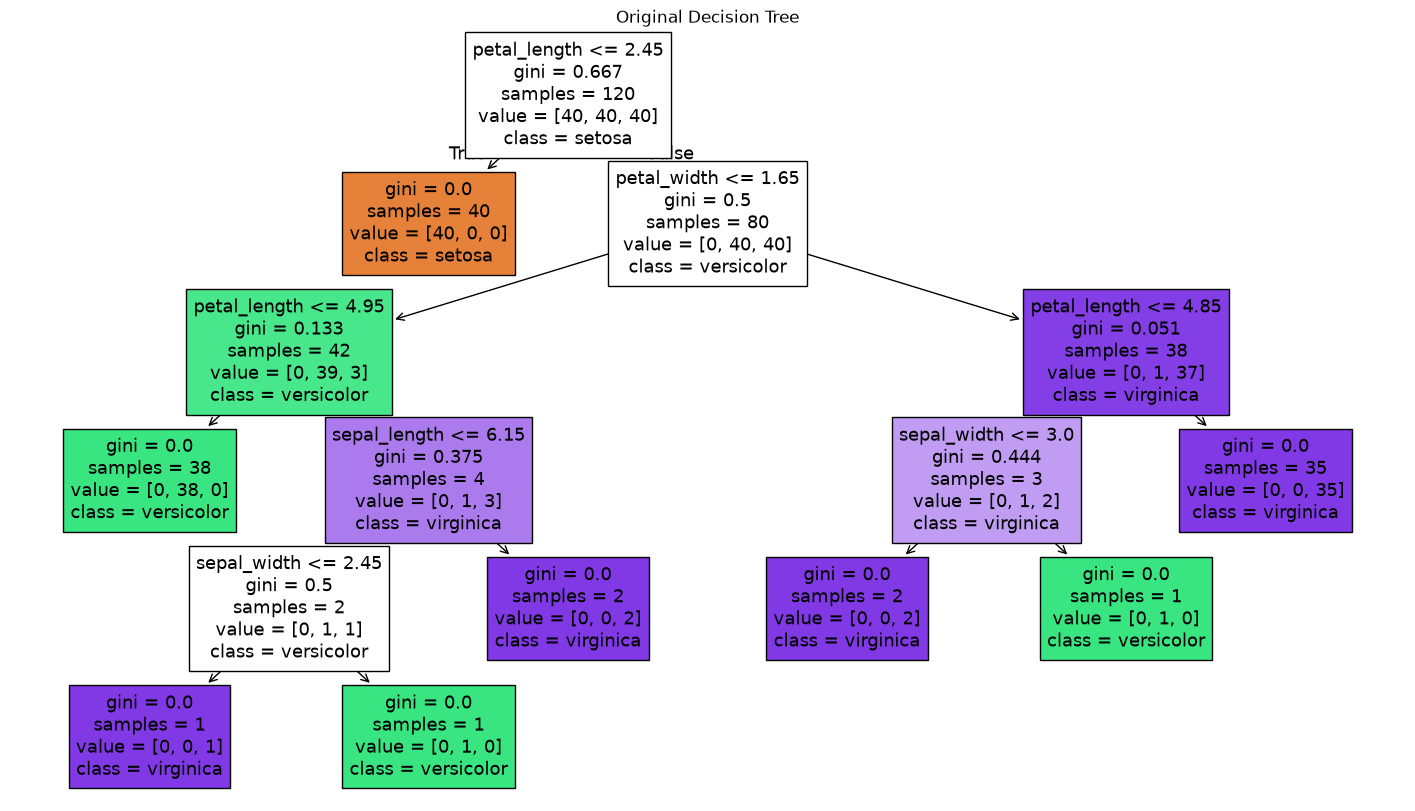


Original Tree Accuracy:
Training Accuracy: 1.0
Testing Accuracy: 0.9333333333333333

Pruned Decision Tree Evaluation:
Accuracy: 0.9666666666666667
F1 Score: 0.9665831244778613

Pruned Tree Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Pruned Tree Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Pruned Tree Accuracy:
Training Accuracy: 0.9833333333333333
Testing Accuracy: 0.9666666666666667

Original vs Pruned Tree:


,Model,Training Accuracy,Testing Accuracy
0,Original Decision Tree,1.000000,0.933333
1,Pruned Decision Tree,0.983333,0.966667


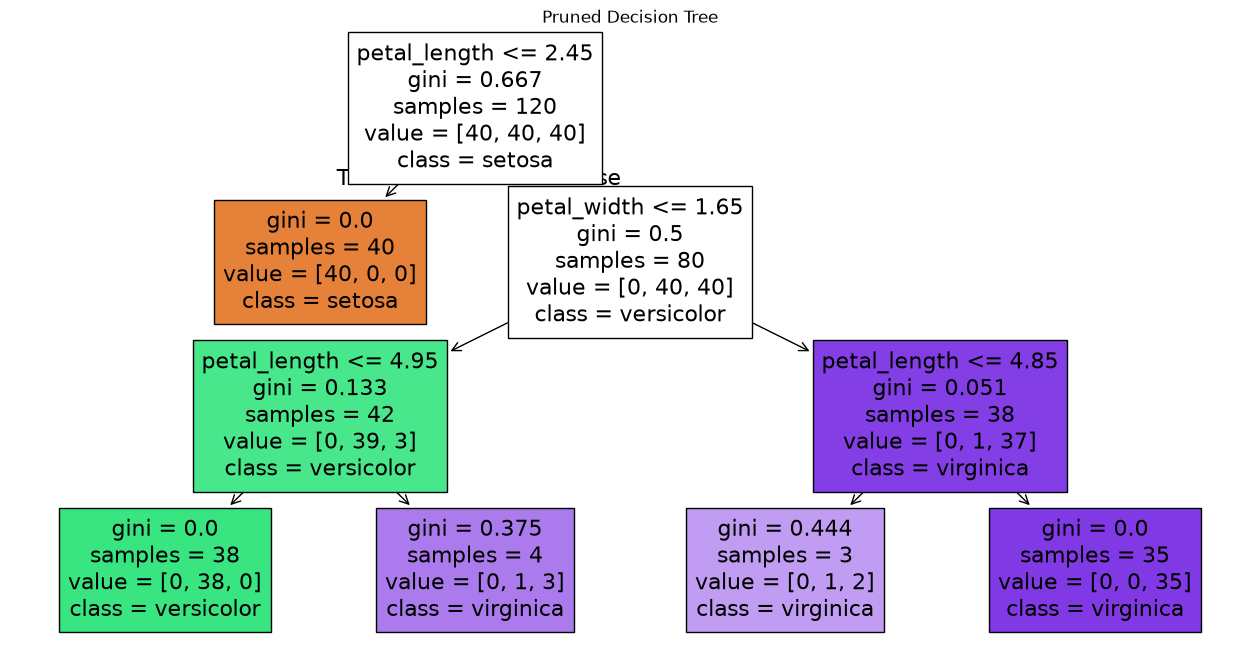


Feature Importance:


,Feature,Importance
2,petal_length,0.579077
3,petal_width,0.420923
1,sepal_width,0.000000
0,sepal_length,0.000000



========== FINAL RESULTS ==========
Original Train Accuracy: 1.0
Original Test Accuracy: 0.9333333333333333
Original F1 Score: 0.9333333333333333

Pruned Train Accuracy: 0.9833333333333333
Pruned Test Accuracy: 0.9666666666666667
Pruned F1 Score: 0.9665831244778613

Decision Tree Task Completed Successfully.


In [1]:
# =========================================================
# LEVEL 2 - TASK 2: DECISION TREE CLASSIFICATION
# IRIS DATASET
# =========================================================


# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# =========================================================
# 2. LOAD THE DATASET
# =========================================================

df = pd.read_csv("dataset/1) iris.csv")


# =========================================================
# 3. EXPLORE THE DATASET
# =========================================================

print("First 5 Rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSpecies Distribution:")
print(df["species"].value_counts())


# =========================================================
# 4. SEPARATE FEATURES AND TARGET
# =========================================================

X = df.drop(columns=["species"])
y = df["species"]

print("\nFeatures:")
display(X.head())

print("\nTarget:")
display(y.head())


# =========================================================
# 5. SPLIT DATA INTO TRAINING AND TESTING SETS
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:")
print(X_train.shape)

print("\nTesting Shape:")
print(X_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())


# =========================================================
# 6. CREATE ORIGINAL DECISION TREE MODEL
# =========================================================

model = DecisionTreeClassifier(
    random_state=42
)


# =========================================================
# 7. TRAIN ORIGINAL MODEL
# =========================================================

model.fit(
    X_train,
    y_train
)


# =========================================================
# 8. MAKE PREDICTIONS
# =========================================================

y_pred = model.predict(
    X_test
)


# =========================================================
# 9. COMPARE ACTUAL AND PREDICTED VALUES
# =========================================================

prediction_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nActual vs Predicted:")
display(prediction_comparison.head(10))


# =========================================================
# 10. EVALUATE ORIGINAL MODEL
# =========================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("\nOriginal Decision Tree Evaluation:")
print("Accuracy:", accuracy)
print("F1 Score:", f1)


# =========================================================
# 11. CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# =========================================================
# 12. CLASSIFICATION REPORT
# =========================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)


# =========================================================
# 13. VISUALIZE ORIGINAL DECISION TREE
# =========================================================

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True
)

plt.title("Original Decision Tree")
plt.show()


# =========================================================
# 14. CHECK FOR OVERFITTING
# =========================================================

original_train_accuracy = model.score(
    X_train,
    y_train
)

original_test_accuracy = model.score(
    X_test,
    y_test
)

print("\nOriginal Tree Accuracy:")

print(
    "Training Accuracy:",
    original_train_accuracy
)

print(
    "Testing Accuracy:",
    original_test_accuracy
)


# =========================================================
# 15. CREATE PRUNED DECISION TREE
# =========================================================

pruned_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)


# =========================================================
# 16. TRAIN PRUNED MODEL
# =========================================================

pruned_model.fit(
    X_train,
    y_train
)


# =========================================================
# 17. MAKE PREDICTIONS WITH PRUNED TREE
# =========================================================

pruned_y_pred = pruned_model.predict(
    X_test
)


# =========================================================
# 18. EVALUATE PRUNED MODEL
# =========================================================

pruned_accuracy = accuracy_score(
    y_test,
    pruned_y_pred
)

pruned_f1 = f1_score(
    y_test,
    pruned_y_pred,
    average="weighted"
)

print("\nPruned Decision Tree Evaluation:")

print(
    "Accuracy:",
    pruned_accuracy
)

print(
    "F1 Score:",
    pruned_f1
)


# =========================================================
# 19. PRUNED TREE CLASSIFICATION REPORT
# =========================================================

print("\nPruned Tree Classification Report:")

print(
    classification_report(
        y_test,
        pruned_y_pred
    )
)


# =========================================================
# 20. PRUNED TREE CONFUSION MATRIX
# =========================================================

pruned_cm = confusion_matrix(
    y_test,
    pruned_y_pred
)

print("\nPruned Tree Confusion Matrix:")
print(pruned_cm)


# =========================================================
# 21. CHECK PRUNED MODEL TRAINING/TESTING ACCURACY
# =========================================================

pruned_train_accuracy = pruned_model.score(
    X_train,
    y_train
)

pruned_test_accuracy = pruned_model.score(
    X_test,
    y_test
)

print("\nPruned Tree Accuracy:")

print(
    "Training Accuracy:",
    pruned_train_accuracy
)

print(
    "Testing Accuracy:",
    pruned_test_accuracy
)


# =========================================================
# 22. COMPARE ORIGINAL VS PRUNED TREE
# =========================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Original Decision Tree",
        "Pruned Decision Tree"
    ],
    "Training Accuracy": [
        original_train_accuracy,
        pruned_train_accuracy
    ],
    "Testing Accuracy": [
        original_test_accuracy,
        pruned_test_accuracy
    ]
})

print("\nOriginal vs Pruned Tree:")
display(model_comparison)


# =========================================================
# 23. VISUALIZE PRUNED DECISION TREE
# =========================================================

plt.figure(figsize=(16, 8))

plot_tree(
    pruned_model,
    feature_names=X.columns,
    class_names=pruned_model.classes_,
    filled=True
)

plt.title("Pruned Decision Tree")
plt.show()


# =========================================================
# 24. FEATURE IMPORTANCE
# =========================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": pruned_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
display(feature_importance)


# =========================================================
# 25. FINAL SUMMARY
# =========================================================

print("\n========== FINAL RESULTS ==========")

print(
    "Original Train Accuracy:",
    original_train_accuracy
)

print(
    "Original Test Accuracy:",
    original_test_accuracy
)

print(
    "Original F1 Score:",
    f1
)

print()

print(
    "Pruned Train Accuracy:",
    pruned_train_accuracy
)

print(
    "Pruned Test Accuracy:",
    pruned_test_accuracy
)

print(
    "Pruned F1 Score:",
    pruned_f1
)

print(
    "\nDecision Tree Task Completed Successfully."
)